<a href="https://colab.research.google.com/github/GuilhermeMulazzani/cgvis-lab03-visualizacao/blob/main/Lab03_visualizacao.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

A fazer o download dos dados da API do SDSS (DR17)...
Dados carregados! A gerar a visualização...


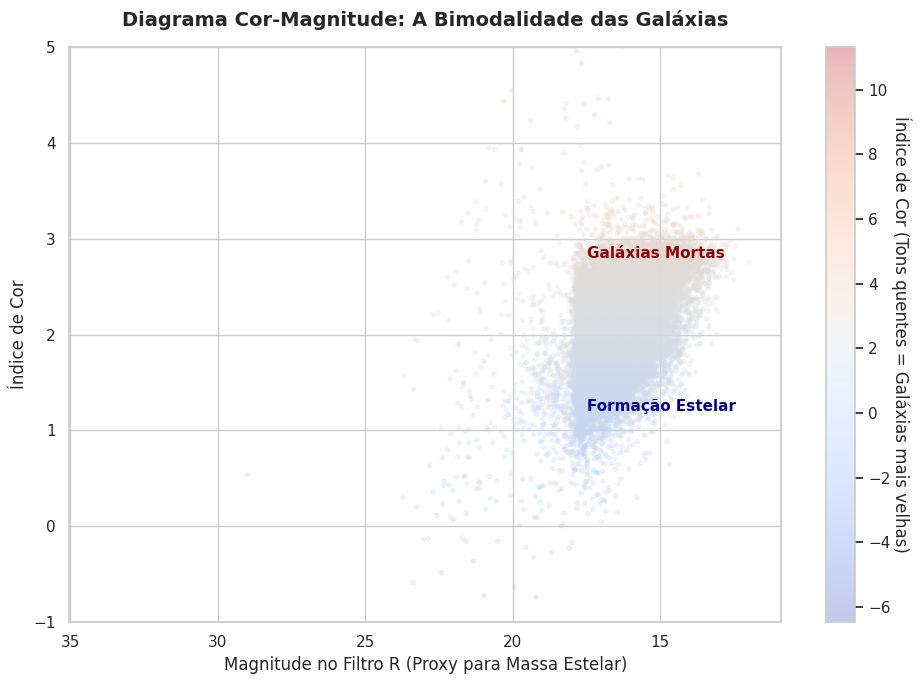

In [12]:
import pandas as pd
import requests
import matplotlib.pyplot as plt
import seaborn as sns
from io import StringIO

print("A fazer o download dos dados da API do SDSS (DR17)...")

# 1. Consulta SQL para extrair 20.000 galáxias com redshift baixo (universo local)
query = """
SELECT TOP 20000
   p.u, p.r, (p.u - p.r) as color_ur,
   p.petroMag_r as magnitude
FROM Galaxy AS p
JOIN SpecObj AS s ON s.bestobjid = p.objid
WHERE p.u BETWEEN 10 AND 25
  AND p.r BETWEEN 10 AND 25
  AND s.z BETWEEN 0.02 AND 0.05
"""

# Fazendo a requisição HTTP direto para os servidores da astronomia
url = "http://skyserver.sdss.org/dr17/SkyServerWS/SearchTools/SqlSearch"
response = requests.get(url, params={'cmd': query, 'format': 'csv'})
df = pd.read_csv(StringIO(response.text), comment='#').dropna()

print("Dados carregados! A gerar a visualização...")

# 2. Configurando o estilo do gráfico para o seu relatório
plt.figure(figsize=(10, 7))
sns.set_theme(style="whitegrid")

# Usando scatter com transparência (alpha=0.3) para lidar com o Overplotting
scatter = plt.scatter(df['magnitude'], df['color_ur'],
                      c=df['color_ur'], cmap='coolwarm',
                      alpha=0.3, s=15, edgecolors='none')

# IMPORTANTE: Na astronomia, magnitudes menores (mais à esquerda)
# significam objetos mais massivos/brilhantes. Por isso invertemos o eixo X!
plt.gca().invert_xaxis()

# Títulos e Rótulos seguindo os critérios de avaliação
plt.title("Diagrama Cor-Magnitude: A Bimodalidade das Galáxias", fontsize=14, pad=15, weight='bold')
plt.xlabel("Magnitude no Filtro R (Proxy para Massa Estelar)", fontsize=12)
plt.ylabel("Índice de Cor", fontsize=12)

# Barra de cores para explicar a codificação
cbar = plt.colorbar(scatter)
cbar.set_label('Índice de Cor (Tons quentes = Galáxias mais velhas)', rotation=270, labelpad=15)

# Textos explicativos diretos no gráfico para destacar a conclusão não-óbvia
plt.text(17.5, 2.8, 'Galáxias Mortas', fontsize=11, color='darkred', weight='bold')
plt.text(17.5, 1.2, 'Formação Estelar', fontsize=11, color='darkblue', weight='bold')

# Renderiza a imagem
plt.tight_layout()
plt.ylim(-1, 5)
plt.show()